# 06 Dependency Modelling

Notebook 05 treated all item-level load uncertainties as independent. This notebook tests whether that assumption changes the system-level risk conclusions.

The purpose of this stage is therefore:

```text
Does dependency between uncertain loads materially change the cascaded cooling-system risk result?
```

Item-level driver analysis is deliberately left to Notebook 07. This notebook focuses on dependency between sampled loads and the resulting subsystem-level risk metrics.


## Dependency modelling approach

I use a Gaussian copula to introduce dependency between uncertain load rows. This method is appropriate here because it separates two modelling choices:

* the marginal uncertainty distribution for each load row remains the same as Notebook 05;
* the dependency structure is introduced through correlated latent normal variables.

This means the triangular and truncated normal load assumptions are preserved, while the simulation can test whether loads moving high together changes the capacity-margin conclusions.

Two dependency structures are tested:

* **global dependency**: all uncertain loads share a common positive factor;
* **subsystem-block dependency**: loads are correlated within HVAC, CW and FW blocks, but each subsystem has its own common factor.

The global case is deliberately conservative because it assumes all uncertain loads tend to move together. The subsystem-block case is less extreme and reflects the possibility that uncertainty is more strongly shared within a subsystem than across the full cooling chain.


## Imports and paths


In [1]:
from pathlib import Path
import math
import time
import warnings

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plotting_available = True
except ModuleNotFoundError:
    plotting_available = False

try:
    from scipy.special import ndtr
    from scipy.stats import truncnorm
    scipy_available = True
except ModuleNotFoundError:
    scipy_available = False

warnings.filterwarnings("ignore", category=FutureWarning)


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (
            (candidate / "outputs" / "tables" / "uncertainty_distribution_parameters.csv").exists()
            and (candidate / "outputs" / "tables" / "monte_carlo_results_summary.csv").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not find the project root. Please open VS Code at the repository folder.")


project_root = find_project_root()
tables_output_path = project_root / "outputs" / "tables"
figures_output_path = project_root / "outputs" / "figures"
tables_output_path.mkdir(parents=True, exist_ok=True)
figures_output_path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Tables output path: {tables_output_path}")
print(f"Figures output path: {figures_output_path}")
# Consistent project colours used in all notebook figures
SYSTEM_ORDER = ["HVAC", "CW", "FW"]
SYSTEM_PALETTE = {
    "HVAC": "#7b5aa6",
    "CW": "#3f83a3",
    "FW": "#5f9f77",
    "Ultimate Heat Sink": "#d78b4b",
}
SYSTEM_COLOUR_LIST = [SYSTEM_PALETTE[system] for system in SYSTEM_ORDER]
SCENARIO_PALETTE = {
    "Scenario Alpha": SYSTEM_PALETTE["HVAC"],
    "Scenario Bravo": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DISTRIBUTION_PALETTE = {
    "Triangular": SYSTEM_PALETTE["CW"],
    "Truncated normal": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DEPENDENCY_PALETTE = {
    "Independent": "#6f7b82",
    "Global Gaussian copula": SYSTEM_PALETTE["HVAC"],
    "Subsystem-block Gaussian copula": SYSTEM_PALETTE["CW"],
}



Project root: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System
Tables output path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\outputs\tables
Figures output path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\outputs\figures


## Load inputs


In [2]:
parameter_path = tables_output_path / "uncertainty_distribution_parameters.csv"
baseline_path = tables_output_path / "monte_carlo_results_summary.csv"

distribution_parameters = pd.read_csv(parameter_path)
independent_baseline = pd.read_csv(baseline_path)

system_order = ["HVAC", "CW", "FW"]
scenario_order = ["Scenario Alpha", "Scenario Bravo"]
margin_case_order = [
    "Case A - CUM",
    "Case B - CMM + CUM",
    "Case C - CMM + CUM + DBM + IGM",
]
distribution_order = ["Triangular", "Truncated normal"]
dependency_model_order = ["Global Gaussian copula", "Subsystem-block Gaussian copula"]
rho_values = [0.25, 0.50, 0.75]

for column, order in [
    ("system", system_order),
    ("scenario", scenario_order),
    ("margin_case", margin_case_order),
]:
    distribution_parameters[column] = pd.Categorical(
        distribution_parameters[column],
        categories=order,
        ordered=True,
    )

print(f"Distribution parameter rows: {len(distribution_parameters):,}")
print(f"Independent baseline rows: {len(independent_baseline):,}")
display(distribution_parameters.head())


Distribution parameter rows: 15,534
Independent baseline rows: 36


,record_id,source_row,pbs_code,teamcenter_id,bom_id,item_description,system,scenario,margin_case,nominal_load_kw,uncertainty_pct,triangular_lower_kw,triangular_mode_kw,triangular_upper_kw,truncnorm_lower_kw,truncnorm_mean_kw,truncnorm_upper_kw,truncnorm_sigma_kw,is_degenerate
0,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Alpha,Case A - CUM,14.872,0.15,12.6412,14.872,17.1028,12.6412,14.872,17.1028,1.138163,False
1,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Alpha,Case B - CMM + CUM,14.872,0.25,11.1540,14.872,18.5900,11.1540,14.872,18.5900,1.896939,False
2,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,14.872,0.35,9.6668,14.872,20.0772,9.6668,14.872,20.0772,2.655714,False
3,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Bravo,Case A - CUM,0.000,0.15,0.0000,0.000,0.0000,0.0000,0.000,0.0000,0.000000,True
4,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Bravo,Case B - CMM + CUM,0.000,0.25,0.0000,0.000,0.0000,0.0000,0.000,0.0000,0.000000,True


## Dependency notation and settings


<!-- dependency-parameter-markdown-table -->

Table. Summary of dependency simulation parameters used in Notebook 06.

| Parameter | Notation | Value used | Reason / interpretation |
|---|---:|---|---|
| Number of simulations | $N$ | 100,000 | Keeps the dependency results comparable with the independent baseline in Notebook 05. |
| Random seed | - | 19046606 | Makes the dependency simulation reproducible while keeping it separate from Notebook 05. |
| Dependency technique | - | Gaussian copula | Preserves the triangular/truncated-normal marginal distributions while introducing controlled positive dependence. |
| Dependency structures | - | Global Gaussian copula; subsystem-block Gaussian copula | Tests a conservative all-loads-move-together case and a less extreme within-subsystem dependency case. |
| Latent correlation values | $\rho$ | 0.25; 0.50; 0.75 | Represents weak, moderate and strong positive dependence. |
| Uncertainty models | - | Triangular; truncated normal | Keeps the dependency analysis consistent with Notebook 05. |
| Operating scenarios | - | Scenario Alpha; Scenario Bravo | Assesses dependency effects across both operating states. |
| Uncertainty cases | - | Case A - CUM; Case B - CMM + CUM; Case C - CMM + CUM + DBM + IGM | Tests dependency under increasing uncertainty inclusion. |
| Cascade treatment | $Y_{s,j}$ | Recomputed each iteration from sampled local subsystem totals | Maintains the HVAC to CW to FW cascade without double-counting propagation rows. |
| Comparison baseline | - | Independent Monte Carlo results from Notebook 05 | Allows dependency effects to be measured as changes from the independent case. |
| Chunk size | - | 150 load rows | Limits memory use when generating correlated samples. |


In [3]:
N_SIMULATIONS = 100_000
RANDOM_SEED = 19046600 + 6
CHUNK_SIZE = 150
PLOT_SAMPLE_SIZE = 2_000

dependency_notation = pd.DataFrame([
    {
        "Notation": "$\\rho$",
        "Meaning": "Latent Gaussian copula correlation",
        "Use in this notebook": "Tested at 0.25, 0.50 and 0.75."
    },
    {
        "Notation": "$Z_{i,j}$",
        "Meaning": "Latent normal value for load item $i$ in iteration $j$",
        "Use in this notebook": "Used to generate correlated uniforms through the Gaussian copula."
    },
    {
        "Notation": "$U_{i,j}$",
        "Meaning": "Correlated uniform quantile",
        "Use in this notebook": "Calculated as $\\Phi(Z_{i,j})$ and passed into the marginal inverse CDF."
    },
    {
        "Notation": "$F_i^{-1}(U_{i,j})$",
        "Meaning": "Inverse marginal distribution for load item $i$",
        "Use in this notebook": "Preserves the triangular or truncated normal marginal assumption from Notebook 05."
    },
    {
        "Notation": "$Y_{s,j}$",
        "Meaning": "Cascaded subsystem load",
        "Use in this notebook": "Recomputed each iteration using sampled local totals."
    },
])

dependency_settings = pd.DataFrame([
    {"Parameter": "Number of simulations", "Value": f"{N_SIMULATIONS:,}"},
    {"Parameter": "Random seed", "Value": RANDOM_SEED},
    {"Parameter": "Dependency technique", "Value": "Gaussian copula"},
    {"Parameter": "Dependency structures", "Value": "; ".join(dependency_model_order)},
    {"Parameter": "Correlation values", "Value": ", ".join(str(value) for value in rho_values)},
    {"Parameter": "Uncertainty distributions", "Value": ", ".join(distribution_order)},
    {"Parameter": "Scenarios", "Value": ", ".join(scenario_order)},
    {"Parameter": "Uncertainty cases", "Value": "; ".join(margin_case_order)},
    {"Parameter": "Cascade treatment", "Value": "Recomputed from sampled local subsystem totals in every iteration"},
])

dependency_notation.to_csv(tables_output_path / "dependency_notation_table.csv", index=False)
dependency_settings.to_csv(tables_output_path / "dependency_simulation_settings.csv", index=False)

display(dependency_notation)
display(dependency_settings)


,Notation,Meaning,Use in this notebook
0,$\rho$,Latent Gaussian copula correlation,"Tested at 0.25, 0.50 and 0.75."
1,"$Z_{i,j}$",Latent normal value for load item $i$ in itera...,Used to generate correlated uniforms through t...
2,"$U_{i,j}$",Correlated uniform quantile,"Calculated as $\Phi(Z_{i,j})$ and passed into ..."
3,"$F_i^{-1}(U_{i,j})$",Inverse marginal distribution for load item $i$,Preserves the triangular or truncated normal m...
4,"$Y_{s,j}$",Cascaded subsystem load,Recomputed each iteration using sampled local ...


,Parameter,Value
0,Number of simulations,"100,000"
1,Random seed,19046606
2,Dependency technique,Gaussian copula
3,Dependency structures,Global Gaussian copula; Subsystem-block Gaussi...
4,Correlation values,"0.25, 0.5, 0.75"
5,Uncertainty distributions,"Triangular, Truncated normal"
6,Scenarios,"Scenario Alpha, Scenario Bravo"
7,Uncertainty cases,Case A - CUM; Case B - CMM + CUM; Case C - CMM...
8,Cascade treatment,Recomputed from sampled local subsystem totals...


## Simulation design summary


In [4]:
dependency_design_summary = (
    distribution_parameters
    .groupby(["scenario", "margin_case", "system"], observed=False)
    .agg(
        records=("record_id", "size"),
        non_degenerate_records=("is_degenerate", lambda values: int((~values).sum())),
        nominal_local_load_kw=("nominal_load_kw", "sum"),
    )
    .reset_index()
)

dependency_design_summary.to_csv(tables_output_path / "dependency_design_summary.csv", index=False)
display(dependency_design_summary)


,scenario,margin_case,system,records,non_degenerate_records,nominal_local_load_kw
0,Scenario Alpha,Case A - CUM,HVAC,2326,252,1026.733447
1,Scenario Alpha,Case A - CUM,CW,198,77,2787.878031
2,Scenario Alpha,Case A - CUM,FW,65,0,7357.754100
3,Scenario Alpha,Case B - CMM + CUM,HVAC,2326,1221,1026.733447
4,Scenario Alpha,Case B - CMM + CUM,CW,198,157,2787.878031
5,Scenario Alpha,Case B - CMM + CUM,FW,65,0,7357.754100
6,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,HVAC,2326,1221,1026.733447
7,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,CW,198,157,2787.878031
8,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,FW,65,53,7357.754100
9,Scenario Bravo,Case A - CUM,HVAC,2326,247,307.292472


## Capacity lookup from independent baseline


In [5]:
capacity_lookup = {
    (row["scenario"], row["subsystem"]): row["capacity_kw"]
    for _, row in independent_baseline.drop_duplicates(["scenario", "subsystem"]).iterrows()
}

deterministic_load_lookup = {
    (row["scenario"], row["subsystem"]): row["deterministic_load_kw"]
    for _, row in independent_baseline.drop_duplicates(["scenario", "subsystem"]).iterrows()
}

display(
    independent_baseline[[
        "scenario",
        "subsystem",
        "deterministic_load_kw",
        "capacity_kw",
    ]]
    .drop_duplicates()
    .sort_values(["scenario", "subsystem"])
)


,scenario,subsystem,deterministic_load_kw,capacity_kw
1,Scenario Alpha,CW,3814.611478,4068.06
2,Scenario Alpha,FW,11172.365578,11734.66
0,Scenario Alpha,HVAC,1026.733447,1159.42
19,Scenario Bravo,CW,1256.638670,1392.08
20,Scenario Bravo,FW,4636.317393,4871.78
18,Scenario Bravo,HVAC,307.292472,372.93


## Copula sampling functions


In [6]:
def triangular_ppf(probabilities, lower, mode, upper):
    probabilities = np.clip(probabilities, 1e-12, 1 - 1e-12)
    span = upper - lower
    mode_fraction = (mode - lower) / span

    left_side = lower + np.sqrt(probabilities * span * (mode - lower))
    right_side = upper - np.sqrt((1 - probabilities) * span * (upper - mode))
    return np.where(probabilities < mode_fraction, left_side, right_side)


def marginal_inverse_cdf(probabilities, row_chunk, distribution_model):
    if distribution_model == "Triangular":
        lower = row_chunk["triangular_lower_kw"].to_numpy(dtype=float)[:, None]
        mode = row_chunk["triangular_mode_kw"].to_numpy(dtype=float)[:, None]
        upper = row_chunk["triangular_upper_kw"].to_numpy(dtype=float)[:, None]
        return triangular_ppf(probabilities, lower, mode, upper)

    if distribution_model == "Truncated normal":
        if not scipy_available:
            raise ModuleNotFoundError("scipy is required for truncated normal dependency sampling.")

        mean = row_chunk["truncnorm_mean_kw"].to_numpy(dtype=float)[:, None]
        lower = row_chunk["truncnorm_lower_kw"].to_numpy(dtype=float)[:, None]
        upper = row_chunk["truncnorm_upper_kw"].to_numpy(dtype=float)[:, None]
        sigma = row_chunk["truncnorm_sigma_kw"].to_numpy(dtype=float)[:, None]

        a = (lower - mean) / sigma
        b = (upper - mean) / sigma
        probabilities = np.clip(probabilities, 1e-12, 1 - 1e-12)
        return truncnorm.ppf(probabilities, a, b, loc=mean, scale=sigma)

    raise ValueError(f"Unknown distribution model: {distribution_model}")


def correlated_uniforms(row_count, n_simulations, rho, common_factor, rng):
    independent_noise = rng.standard_normal(size=(row_count, n_simulations))
    latent_normal = math.sqrt(rho) * common_factor[None, :] + math.sqrt(1 - rho) * independent_noise
    return ndtr(latent_normal)


def get_common_factors(dependency_model, n_simulations, rng):
    if dependency_model == "Global Gaussian copula":
        global_factor = rng.standard_normal(n_simulations)
        return {system: global_factor for system in system_order}

    if dependency_model == "Subsystem-block Gaussian copula":
        return {
            system: rng.standard_normal(n_simulations)
            for system in system_order
        }

    raise ValueError(f"Unknown dependency model: {dependency_model}")


def sample_dependent_local_totals(parameters, distribution_model, dependency_model, rho, n_simulations, rng, chunk_size):
    common_factors = get_common_factors(dependency_model, n_simulations, rng)
    local_totals = {
        system: np.zeros(n_simulations, dtype=float)
        for system in system_order
    }

    for system in system_order:
        system_parameters = parameters[parameters["system"] == system].copy()
        fixed_parameters = system_parameters[system_parameters["is_degenerate"]]
        variable_parameters = system_parameters[~system_parameters["is_degenerate"]].reset_index(drop=True)

        local_totals[system] += fixed_parameters["nominal_load_kw"].sum()

        for start in range(0, len(variable_parameters), chunk_size):
            row_chunk = variable_parameters.iloc[start:start + chunk_size]
            probabilities = correlated_uniforms(
                len(row_chunk),
                n_simulations,
                rho,
                common_factors[system],
                rng,
            )
            sampled_rows = marginal_inverse_cdf(probabilities, row_chunk, distribution_model)
            local_totals[system] += sampled_rows.sum(axis=0)

    return local_totals


def rebuild_cascade(local_totals):
    hvac_total = local_totals["HVAC"]
    cw_total = local_totals["CW"] + hvac_total
    fw_total = local_totals["FW"] + cw_total

    return {
        "HVAC": hvac_total,
        "CW": cw_total,
        "FW": fw_total,
    }


def rule_of_three_upper_bound(overload_count, n_simulations):
    if overload_count == 0:
        return 3 / n_simulations
    return np.nan


def summarise_dependent_subsystem(values, scenario, margin_case, distribution_model, dependency_model, rho, subsystem):
    capacity = capacity_lookup[(scenario, subsystem)]
    deterministic_load = deterministic_load_lookup[(scenario, subsystem)]
    overload = values > capacity
    overload_count = int(overload.sum())
    overload_probability = overload_count / len(values)
    standard_error = math.sqrt(overload_probability * (1 - overload_probability) / len(values))
    confidence_delta = 1.96 * standard_error

    p95_load = np.percentile(values, 95)
    p99_load = np.percentile(values, 99)
    p95_spare = capacity - p95_load
    p99_spare = capacity - p99_load

    return {
        "scenario": scenario,
        "margin_case": margin_case,
        "distribution_model": distribution_model,
        "dependency_model": dependency_model,
        "rho": rho,
        "subsystem": subsystem,
        "simulations": len(values),
        "deterministic_load_kw": deterministic_load,
        "capacity_kw": capacity,
        "mean_load_kw": values.mean(),
        "std_load_kw": values.std(ddof=1),
        "p95_load_kw": p95_load,
        "p99_load_kw": p99_load,
        "max_load_kw": values.max(),
        "p95_spare_capacity_kw": p95_spare,
        "p99_spare_capacity_kw": p99_spare,
        "p95_load_to_capacity_ratio": p95_load / capacity,
        "p99_load_to_capacity_ratio": p99_load / capacity,
        "max_load_to_capacity_ratio": values.max() / capacity,
        "p95_capacity_margin_pct": p95_spare / capacity * 100,
        "p99_capacity_margin_pct": p99_spare / capacity * 100,
        "overload_count": overload_count,
        "overload_probability": overload_probability,
        "overload_probability_pct": overload_probability * 100,
        "overload_probability_ci95_lower": max(0, overload_probability - confidence_delta),
        "overload_probability_ci95_upper": min(1, overload_probability + confidence_delta),
        "rule_of_three_upper_if_zero": rule_of_three_upper_bound(overload_count, len(values)),
    }


## Run dependency simulations


In [7]:
rng = np.random.default_rng(RANDOM_SEED)
dependency_summary_rows = []
dependency_run_log_rows = []

start_time = time.perf_counter()

for scenario in scenario_order:
    for margin_case in margin_case_order:
        combo_parameters = distribution_parameters[
            (distribution_parameters["scenario"] == scenario) &
            (distribution_parameters["margin_case"] == margin_case)
        ].copy()

        for distribution_model in distribution_order:
            for dependency_model in dependency_model_order:
                for rho in rho_values:
                    run_start = time.perf_counter()
                    local_totals = sample_dependent_local_totals(
                        combo_parameters,
                        distribution_model,
                        dependency_model,
                        rho,
                        N_SIMULATIONS,
                        rng,
                        CHUNK_SIZE,
                    )
                    cascaded_totals = rebuild_cascade(local_totals)

                    for subsystem in system_order:
                        dependency_summary_rows.append(
                            summarise_dependent_subsystem(
                                cascaded_totals[subsystem],
                                scenario,
                                margin_case,
                                distribution_model,
                                dependency_model,
                                rho,
                                subsystem,
                            )
                        )

                    dependency_run_log_rows.append({
                        "scenario": scenario,
                        "margin_case": margin_case,
                        "distribution_model": distribution_model,
                        "dependency_model": dependency_model,
                        "rho": rho,
                        "runtime_seconds": time.perf_counter() - run_start,
                        "parameter_rows": len(combo_parameters),
                        "non_degenerate_rows": int((~combo_parameters["is_degenerate"]).sum()),
                    })

                    print(
                        f"Completed {scenario} | {margin_case} | {distribution_model} | "
                        f"{dependency_model} | rho={rho:.2f} "
                        f"in {dependency_run_log_rows[-1]['runtime_seconds']:.1f} seconds"
                    )

total_runtime_seconds = time.perf_counter() - start_time
print(f"Total dependency simulation runtime: {total_runtime_seconds:.1f} seconds")


Completed Scenario Alpha | Case A - CUM | Triangular | Global Gaussian copula | rho=0.25 in 2.2 seconds
Completed Scenario Alpha | Case A - CUM | Triangular | Global Gaussian copula | rho=0.50 in 2.3 seconds
Completed Scenario Alpha | Case A - CUM | Triangular | Global Gaussian copula | rho=0.75 in 2.2 seconds
Completed Scenario Alpha | Case A - CUM | Triangular | Subsystem-block Gaussian copula | rho=0.25 in 2.2 seconds
Completed Scenario Alpha | Case A - CUM | Triangular | Subsystem-block Gaussian copula | rho=0.50 in 2.3 seconds
Completed Scenario Alpha | Case A - CUM | Triangular | Subsystem-block Gaussian copula | rho=0.75 in 2.3 seconds
Completed Scenario Alpha | Case A - CUM | Truncated normal | Global Gaussian copula | rho=0.25 in 8.2 seconds
Completed Scenario Alpha | Case A - CUM | Truncated normal | Global Gaussian copula | rho=0.50 in 7.9 seconds
Completed Scenario Alpha | Case A - CUM | Truncated normal | Global Gaussian copula | rho=0.75 in 8.0 seconds
Completed Scenario 

## Dependency simulation results


In [8]:
dependency_results = pd.DataFrame(dependency_summary_rows)
dependency_run_log = pd.DataFrame(dependency_run_log_rows)

dependency_results = dependency_results.sort_values([
    "scenario",
    "margin_case",
    "distribution_model",
    "dependency_model",
    "rho",
    "subsystem",
]).reset_index(drop=True)

dependency_results.to_csv(tables_output_path / "dependency_results_summary.csv", index=False)
dependency_run_log.to_csv(tables_output_path / "dependency_run_log.csv", index=False)

display(dependency_results)
display(dependency_run_log)


,scenario,margin_case,distribution_model,dependency_model,rho,subsystem,simulations,deterministic_load_kw,capacity_kw,mean_load_kw,...,p99_load_to_capacity_ratio,max_load_to_capacity_ratio,p95_capacity_margin_pct,p99_capacity_margin_pct,overload_count,overload_probability,overload_probability_pct,overload_probability_ci95_lower,overload_probability_ci95_upper,rule_of_three_upper_if_zero
0,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,CW,100000,3814.611478,4068.06,3814.656131,...,0.946406,0.951726,5.595961,5.359441,0,0.00000,0.000,0.000000,0.000000,0.00003
1,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,FW,100000,11172.365578,11734.66,11172.410231,...,0.955101,0.956946,4.571866,4.489872,0,0.00000,0.000,0.000000,0.000000,0.00003
2,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,HVAC,100000,1026.733447,1159.42,1026.746891,...,0.893142,0.896991,10.896289,10.685783,0,0.00000,0.000,0.000000,0.000000,0.00003
3,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.50,CW,100000,3814.611478,4068.06,3814.626122,...,0.949547,0.955037,5.344772,5.045270,0,0.00000,0.000,0.000000,0.000000,0.00003
4,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.50,FW,100000,11172.365578,11734.66,11172.380222,...,0.956190,0.958094,4.484786,4.380958,0,0.00000,0.000,0.000000,0.000000,0.00003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.50,FW,100000,4636.317393,4871.78,4636.593329,...,0.996315,1.026674,1.557577,0.368493,545,0.00545,0.545,0.004994,0.005906,NaN
212,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.50,HVAC,100000,307.292472,372.93,307.390679,...,0.948296,0.994190,8.321897,5.170362,0,0.00000,0.000,0.000000,0.000000,0.00003
213,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.75,CW,100000,1256.638670,1392.08,1256.864905,...,0.995601,1.037882,2.826398,0.439896,671,0.00671,0.671,0.006204,0.007216,NaN
214,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.75,FW,100000,4636.317393,4871.78,4636.308537,...,1.002960,1.030915,1.036548,-0.295971,1534,0.01534,1.534,0.014578,0.016102,NaN


,scenario,margin_case,distribution_model,dependency_model,rho,runtime_seconds,parameter_rows,non_degenerate_rows
0,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,2.202721,2589,329
1,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.50,2.257525,2589,329
2,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.75,2.230456,2589,329
3,Scenario Alpha,Case A - CUM,Triangular,Subsystem-block Gaussian copula,0.25,2.239248,2589,329
4,Scenario Alpha,Case A - CUM,Triangular,Subsystem-block Gaussian copula,0.50,2.287374,2589,329
...,...,...,...,...,...,...,...,...
67,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.50,10.589307,2589,447
68,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,10.583194,2589,447
69,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.25,10.530607,2589,447
70,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.50,10.314261,2589,447


## Compare dependency runs with independent baseline


In [9]:
baseline_columns = [
    "scenario",
    "margin_case",
    "distribution_model",
    "subsystem",
    "p99_load_to_capacity_ratio",
    "p99_spare_capacity_kw",
    "p99_load_kw",
    "overload_probability_pct",
]

baseline_for_comparison = independent_baseline[baseline_columns].rename(columns={
    "p99_load_to_capacity_ratio": "independent_p99_load_to_capacity_ratio",
    "p99_spare_capacity_kw": "independent_p99_spare_capacity_kw",
    "p99_load_kw": "independent_p99_load_kw",
    "overload_probability_pct": "independent_overload_probability_pct",
})

dependency_comparison = dependency_results.merge(
    baseline_for_comparison,
    on=["scenario", "margin_case", "distribution_model", "subsystem"],
    how="left",
)

dependency_comparison["delta_p99_load_to_capacity_ratio"] = (
    dependency_comparison["p99_load_to_capacity_ratio"] -
    dependency_comparison["independent_p99_load_to_capacity_ratio"]
)
dependency_comparison["delta_p99_spare_capacity_kw"] = (
    dependency_comparison["p99_spare_capacity_kw"] -
    dependency_comparison["independent_p99_spare_capacity_kw"]
)
dependency_comparison["delta_p99_load_kw"] = (
    dependency_comparison["p99_load_kw"] -
    dependency_comparison["independent_p99_load_kw"]
)
dependency_comparison["delta_overload_probability_pct"] = (
    dependency_comparison["overload_probability_pct"] -
    dependency_comparison["independent_overload_probability_pct"]
)

dependency_comparison.to_csv(tables_output_path / "dependency_comparison_to_independent.csv", index=False)
display(dependency_comparison)


,scenario,margin_case,distribution_model,dependency_model,rho,subsystem,simulations,deterministic_load_kw,capacity_kw,mean_load_kw,...,overload_probability_ci95_upper,rule_of_three_upper_if_zero,independent_p99_load_to_capacity_ratio,independent_p99_spare_capacity_kw,independent_p99_load_kw,independent_overload_probability_pct,delta_p99_load_to_capacity_ratio,delta_p99_spare_capacity_kw,delta_p99_load_kw,delta_overload_probability_pct
0,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,CW,100000,3814.611478,4068.06,3814.656131,...,0.000000,0.00003,0.940116,243.610225,3824.449775,0.0,0.006289,-25.584944,25.584944,0.000
1,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,FW,100000,11172.365578,11734.66,11172.410231,...,0.000000,0.00003,0.952921,552.456125,11182.203875,0.0,0.002180,-25.584944,25.584944,0.000
2,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,HVAC,100000,1026.733447,1159.42,1026.746891,...,0.000000,0.00003,0.887998,129.856942,1029.563058,0.0,0.005144,-5.963839,5.963839,0.000
3,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.50,CW,100000,3814.611478,4068.06,3814.626122,...,0.000000,0.00003,0.940116,243.610225,3824.449775,0.0,0.009431,-38.365623,38.365623,0.000
4,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.50,FW,100000,11172.365578,11734.66,11172.380222,...,0.000000,0.00003,0.952921,552.456125,11182.203875,0.0,0.003269,-38.365623,38.365623,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.50,FW,100000,4636.317393,4871.78,4636.593329,...,0.005906,NaN,0.978616,104.179664,4767.600336,0.0,0.017699,-86.227503,86.227503,0.545
212,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.50,HVAC,100000,307.292472,372.93,307.390679,...,0.000000,0.00003,0.852850,54.876519,318.053481,0.0,0.095446,-35.594688,35.594688,0.000
213,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.75,CW,100000,1256.638670,1392.08,1256.864905,...,0.007216,NaN,0.925328,103.949710,1288.130290,0.0,0.070273,-97.826007,97.826007,0.671
214,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.75,FW,100000,4636.317393,4871.78,4636.308537,...,0.016102,NaN,0.978616,104.179664,4767.600336,0.0,0.024344,-118.598711,118.598711,1.534


## Most constrained dependency cases


In [10]:
dependency_most_constrained = (
    dependency_comparison
    .sort_values(
        ["p99_load_to_capacity_ratio", "p99_spare_capacity_kw"],
        ascending=[False, True],
    )
    .head(15)
    [[
        "scenario",
        "margin_case",
        "distribution_model",
        "dependency_model",
        "rho",
        "subsystem",
        "capacity_kw",
        "p99_load_kw",
        "p99_spare_capacity_kw",
        "p99_capacity_margin_pct",
        "p99_load_to_capacity_ratio",
        "delta_p99_load_to_capacity_ratio",
        "delta_p99_spare_capacity_kw",
        "overload_probability_pct",
        "rule_of_three_upper_if_zero",
    ]]
    .reset_index(drop=True)
)

dependency_most_constrained.to_csv(tables_output_path / "dependency_most_constrained_cases.csv", index=False)
display(dependency_most_constrained)


,scenario,margin_case,distribution_model,dependency_model,rho,subsystem,capacity_kw,p99_load_kw,p99_spare_capacity_kw,p99_capacity_margin_pct,p99_load_to_capacity_ratio,delta_p99_load_to_capacity_ratio,delta_p99_spare_capacity_kw,overload_probability_pct,rule_of_three_upper_if_zero
0,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,FW,4871.78,5003.217759,-131.437759,-2.697941,1.026979,0.048364,-235.617423,9.225,NaN
1,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,CW,1392.08,1423.975599,-31.895599,-2.291219,1.022912,0.097584,-135.845309,4.077,NaN
2,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,FW,4871.78,4974.560623,-102.780623,-2.109714,1.021097,0.044640,-217.474284,7.035,NaN
3,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,FW,11734.66,11971.819811,-237.159811,-2.021020,1.020210,0.042638,-500.341037,6.942,NaN
4,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,CW,4068.06,4135.878855,-67.818855,-1.667106,1.016671,0.066238,-269.458982,4.488,NaN
5,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.50,FW,4871.78,4950.565242,-78.785242,-1.617176,1.016172,0.037556,-182.964906,5.116,NaN
6,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,FW,11734.66,11901.723648,-167.063648,-1.423677,1.014237,0.038693,-454.044156,5.077,NaN
7,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,CW,1392.08,1410.566471,-18.486471,-1.327975,1.013280,0.089931,-125.191281,2.558,NaN
8,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.50,FW,4871.78,4928.096754,-56.316754,-1.155979,1.011560,0.035102,-171.010415,3.592,NaN
9,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.50,FW,11734.66,11859.825389,-125.165389,-1.066630,1.010666,0.033094,-388.346615,3.457,NaN


## Dependency plots


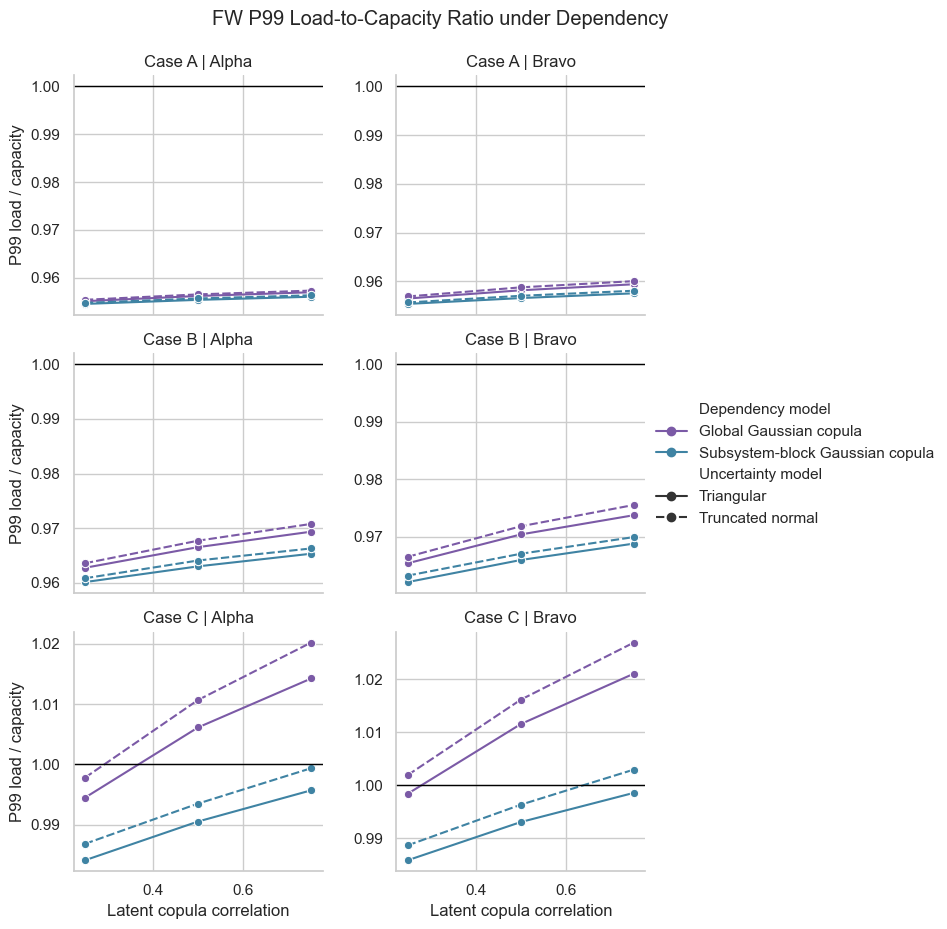

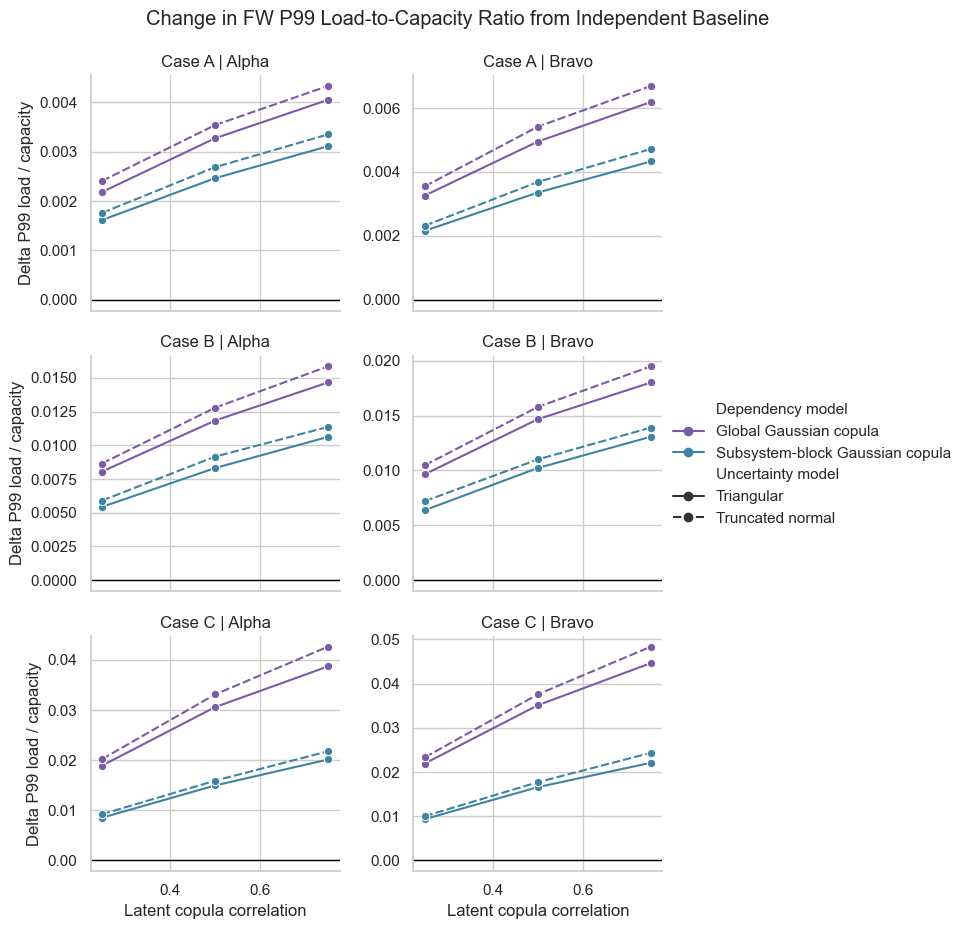

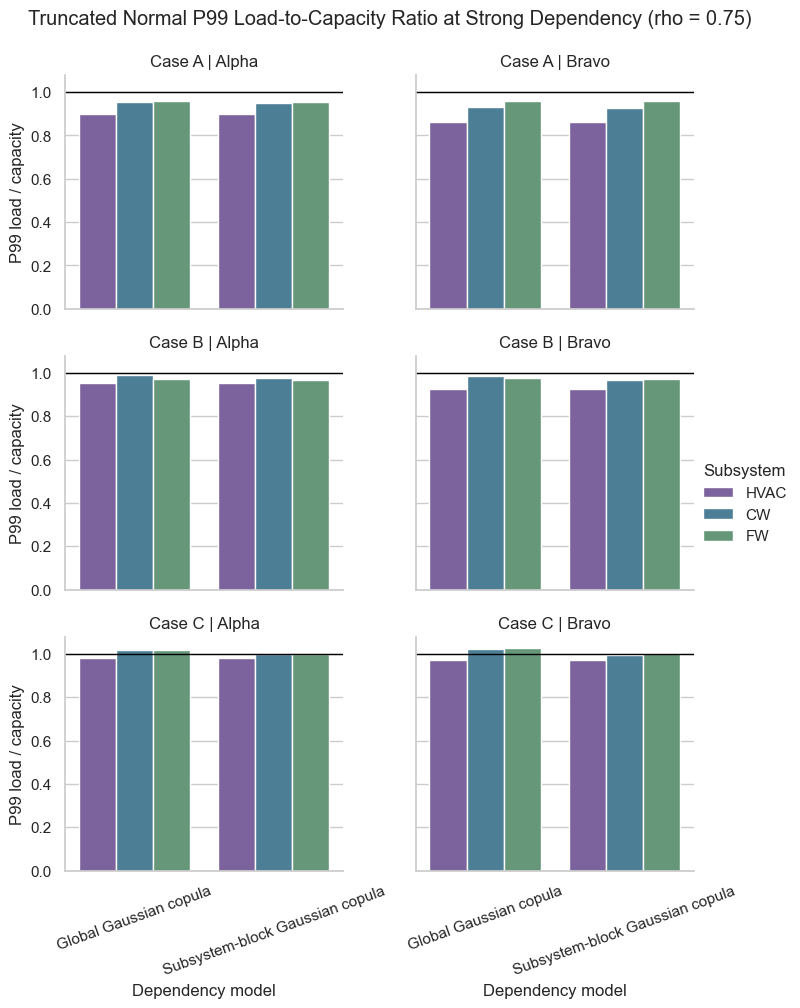

In [3]:
if plotting_available:
    sns.set_theme(style="whitegrid")

    if "dependency_results" not in globals():
        dependency_results = pd.read_csv(tables_output_path / "dependency_results_summary.csv")
    if "dependency_comparison" not in globals():
        dependency_comparison = pd.read_csv(tables_output_path / "dependency_comparison_to_independent.csv")
    if "rho_values" not in globals():
        rho_values = [0.25, 0.50, 0.75]

    plot_data = dependency_results.copy()
    plot_data["scenario_label"] = plot_data["scenario"].map({
        "Scenario Alpha": "Alpha",
        "Scenario Bravo": "Bravo",
    })
    plot_data["margin_case_label"] = plot_data["margin_case"].map({
        "Case A - CUM": "Case A",
        "Case B - CMM + CUM": "Case B",
        "Case C - CMM + CUM + DBM + IGM": "Case C",
    })
    plot_data["Dependency model"] = plot_data["dependency_model"]
    plot_data["Uncertainty model"] = plot_data["distribution_model"]

    fw_plot = plot_data[plot_data["subsystem"] == "FW"].copy()
    graph = sns.relplot(
        data=fw_plot,
        x="rho",
        y="p99_load_to_capacity_ratio",
        hue="Dependency model",
        hue_order=["Global Gaussian copula", "Subsystem-block Gaussian copula"],
        palette=DEPENDENCY_PALETTE,
        style="Uncertainty model",
        row="margin_case_label",
        col="scenario_label",
        kind="line",
        marker="o",
        height=3.0,
        aspect=1.2,
        facet_kws={"sharey": False},
    )
    graph.set_titles("{row_name} | {col_name}")
    graph.fig.suptitle("FW P99 Load-to-Capacity Ratio under Dependency", y=1.03)
    graph.set_axis_labels("Latent copula correlation", "P99 load / capacity")
    for axis in graph.axes.flat:
        axis.axhline(1.0, color="black", linewidth=1)
    graph.savefig(figures_output_path / "dependency_fw_p99_load_to_capacity_ratio.png", dpi=150, bbox_inches="tight")
    plt.show()

    comparison_plot = dependency_comparison.copy()
    comparison_plot["scenario_label"] = comparison_plot["scenario"].map({
        "Scenario Alpha": "Alpha",
        "Scenario Bravo": "Bravo",
    })
    comparison_plot["margin_case_label"] = comparison_plot["margin_case"].map({
        "Case A - CUM": "Case A",
        "Case B - CMM + CUM": "Case B",
        "Case C - CMM + CUM + DBM + IGM": "Case C",
    })
    comparison_plot["Dependency model"] = comparison_plot["dependency_model"]
    comparison_plot["Uncertainty model"] = comparison_plot["distribution_model"]

    graph = sns.relplot(
        data=comparison_plot[comparison_plot["subsystem"] == "FW"],
        x="rho",
        y="delta_p99_load_to_capacity_ratio",
        hue="Dependency model",
        hue_order=["Global Gaussian copula", "Subsystem-block Gaussian copula"],
        palette=DEPENDENCY_PALETTE,
        style="Uncertainty model",
        row="margin_case_label",
        col="scenario_label",
        kind="line",
        marker="o",
        height=3.0,
        aspect=1.2,
        facet_kws={"sharey": False},
    )
    graph.set_titles("{row_name} | {col_name}")
    graph.fig.suptitle("Change in FW P99 Load-to-Capacity Ratio from Independent Baseline", y=1.03)
    graph.set_axis_labels("Latent copula correlation", "Delta P99 load / capacity")
    for axis in graph.axes.flat:
        axis.axhline(0, color="black", linewidth=1)
    graph.savefig(figures_output_path / "dependency_delta_from_independent_fw.png", dpi=150, bbox_inches="tight")
    plt.show()

    strongest_dependency = plot_data[
        (plot_data["rho"] == max(rho_values)) &
        (plot_data["distribution_model"] == "Truncated normal")
    ].copy()
    graph = sns.catplot(
        data=strongest_dependency,
        x="Dependency model",
        y="p99_load_to_capacity_ratio",
        hue="subsystem",
        order=["Global Gaussian copula", "Subsystem-block Gaussian copula"],
        hue_order=SYSTEM_ORDER,
        palette=SYSTEM_PALETTE,
        row="margin_case_label",
        col="scenario_label",
        kind="bar",
        height=3.0,
        aspect=1.2,
        sharey=True,
    )
    graph.set_titles("{row_name} | {col_name}")
    graph.fig.suptitle("Truncated Normal P99 Load-to-Capacity Ratio at Strong Dependency (rho = 0.75)", y=1.03)
    if graph._legend is not None:
        graph._legend.set_title("Subsystem")
    graph.set_axis_labels("Dependency model", "P99 load / capacity")
    for axis in graph.axes.flat:
        axis.axhline(1.0, color="black", linewidth=1)
        axis.set_ylim(0, 1.08)
        axis.tick_params(axis="x", rotation=20)
    graph.savefig(figures_output_path / "dependency_strong_rho_p99_load_to_capacity_ratio.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping plots because matplotlib and seaborn are not installed in this Python environment.")


## Interpretation


In [12]:
largest_dependency_effect = (
    dependency_comparison
    .assign(abs_delta_ratio=lambda frame: frame["delta_p99_load_to_capacity_ratio"].abs())
    .sort_values("abs_delta_ratio", ascending=False)
    .head(10)
    [[
        "scenario",
        "margin_case",
        "distribution_model",
        "dependency_model",
        "rho",
        "subsystem",
        "p99_load_to_capacity_ratio",
        "independent_p99_load_to_capacity_ratio",
        "delta_p99_load_to_capacity_ratio",
        "p99_spare_capacity_kw",
        "delta_p99_spare_capacity_kw",
        "overload_probability_pct",
    ]]
    .reset_index(drop=True)
)

largest_dependency_effect.to_csv(tables_output_path / "dependency_largest_effects.csv", index=False)
display(largest_dependency_effect)


,scenario,margin_case,distribution_model,dependency_model,rho,subsystem,p99_load_to_capacity_ratio,independent_p99_load_to_capacity_ratio,delta_p99_load_to_capacity_ratio,p99_spare_capacity_kw,delta_p99_spare_capacity_kw,overload_probability_pct
0,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.75,HVAC,0.971428,0.852850,0.118578,10.655299,-44.221220,0.000
1,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,HVAC,0.970500,0.852850,0.117649,11.001508,-43.875011,0.000
2,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Subsystem-block Gaussian copula,0.75,HVAC,0.959021,0.850674,0.108347,15.282182,-40.406010,0.000
3,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,HVAC,0.958643,0.850674,0.107969,15.423139,-40.265052,0.000
4,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,CW,1.022912,0.925328,0.097584,-31.895599,-135.845309,4.077
5,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.50,HVAC,0.948296,0.852850,0.095446,19.281831,-35.594688,0.000
6,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.50,HVAC,0.947610,0.852850,0.094760,19.537726,-35.338792,0.000
7,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,CW,1.013280,0.923349,0.089931,-18.486471,-125.191281,2.558
8,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Subsystem-block Gaussian copula,0.50,HVAC,0.938182,0.850674,0.087508,23.053695,-32.634496,0.000
9,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.50,HVAC,0.938182,0.850674,0.087508,23.053753,-32.634438,0.000


## Notebook 06 conclusion

This notebook tests whether positive dependency between uncertain loads changes the system-level risk conclusions from the independent Monte Carlo baseline. The analysis uses a Gaussian copula so that the marginal uncertainty distributions remain consistent with Notebook 05.

The outputs from this notebook should be read alongside Notebook 05:

* Notebook 05 establishes the independent baseline;
* Notebook 06 tests global and subsystem-block dependency assumptions;
* Notebook 07 then investigates which individual loads drive the system response.
